In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

classes_description = ["0. Normal, Left/Right bundle branch block, Atrial escape, Nodal escape",
           "1. Atrial premature, Aberrant atrial premature, Nodal premature, Supra-ventricular premature",
           "2. Premature ventricular contraction, Ventricular escape",
           "3. Fusion of ventricular and norma",
           "4. Paced, Fusion of paced and normal, Unclassifiable"]

Bierzemy dane z pliku, ostatnia kolumna to wynik z classes_description dla danego badania

In [2]:
train_path = "data/mitbih_train.csv"
train_data = pd.read_csv(train_path, header=None, usecols=range(188))

X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]

In [3]:
test_path = "data/mitbih_test.csv"
test_data = pd.read_csv(test_path, header=None, usecols=range(188))

X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]


wizualizacja dla roznych typow badań

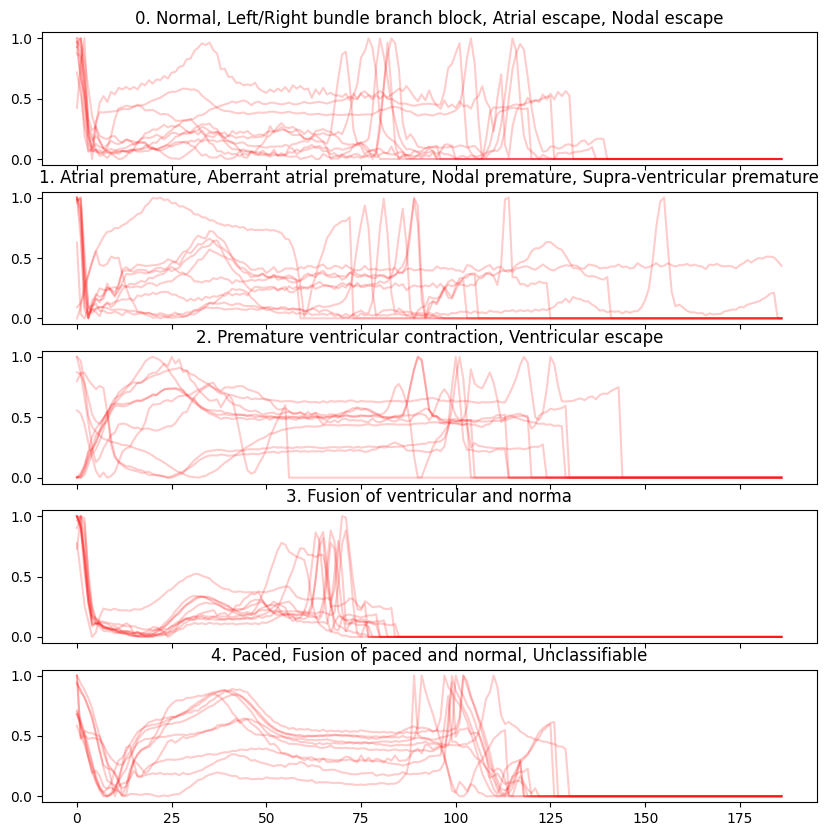

In [ ]:
def plot(x_data, y_data, classes_description=classes_description, plots_per_class=25):
    classes = range(len(classes_description))
    f, ax = plt.subplots(len(classes), sharex=True, sharey=True, figsize=(10,10))
    for i in classes:
        for j in range(plots_per_class):
            ax[i].set_title(classes_description[i])
            
            # jesli y_data (wynik) jest rowny rysowanej klasie to rysuj jego x_data (caly ten wiersz)
            ax[i].plot(x_data[y_data == i].iloc[j, :], color="red", alpha=.2)
            
plot(X_train, y_train)

mapa ciepła dla tych klas. oś x to czas, oś y to wiersz z datasetu.
robimy to po wykresy wyzej moga byc nieczytelne dla wiekszej ilosci probek.


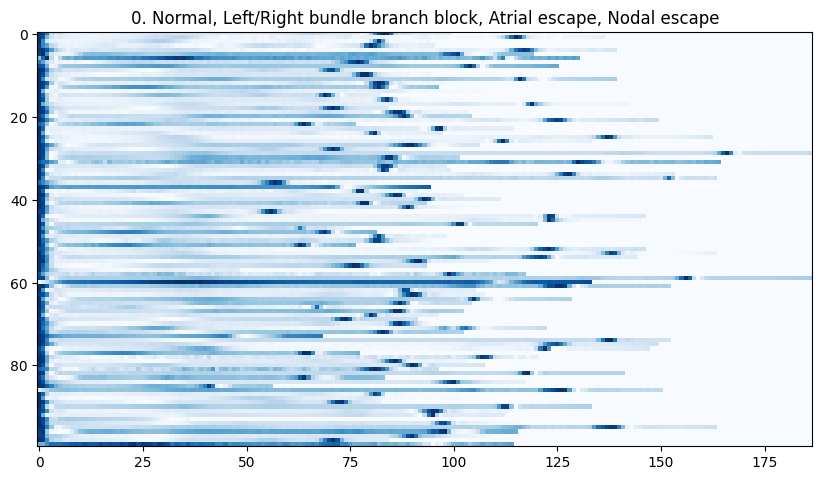

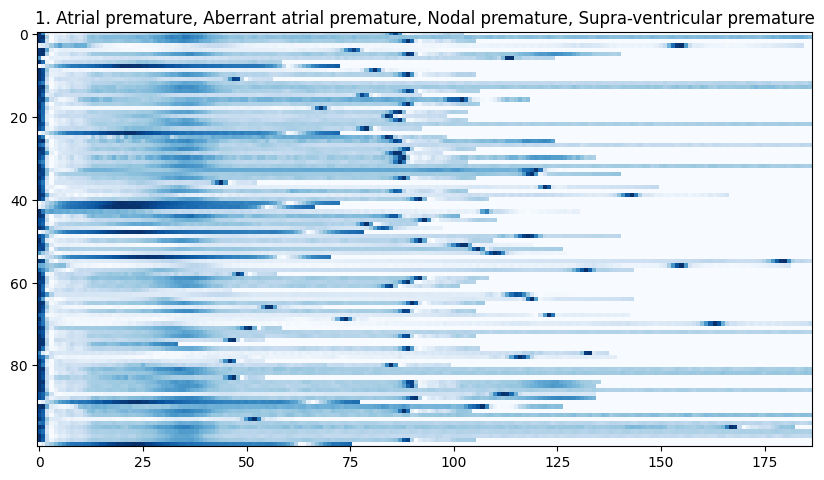

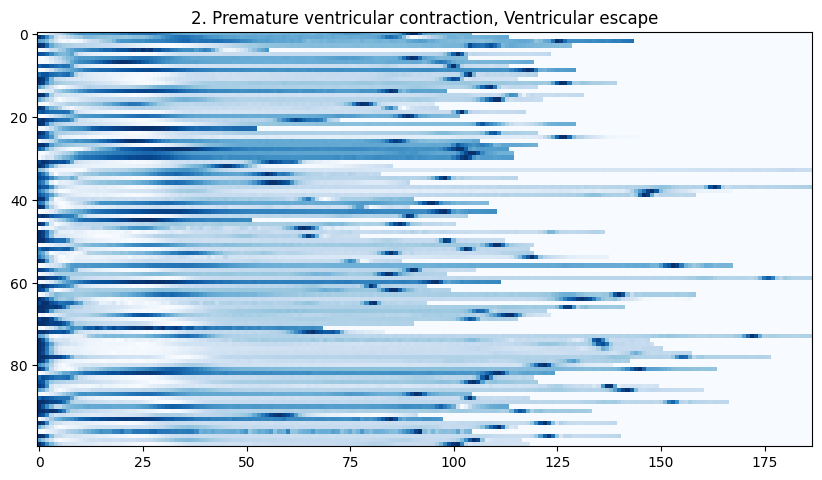

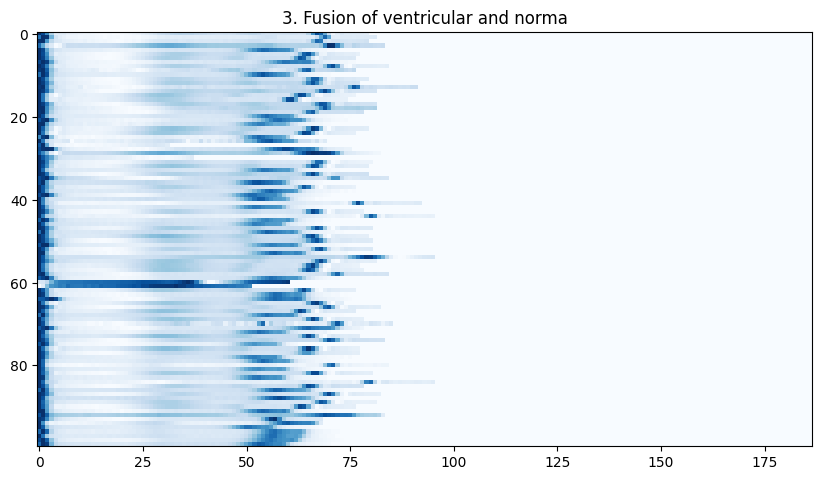

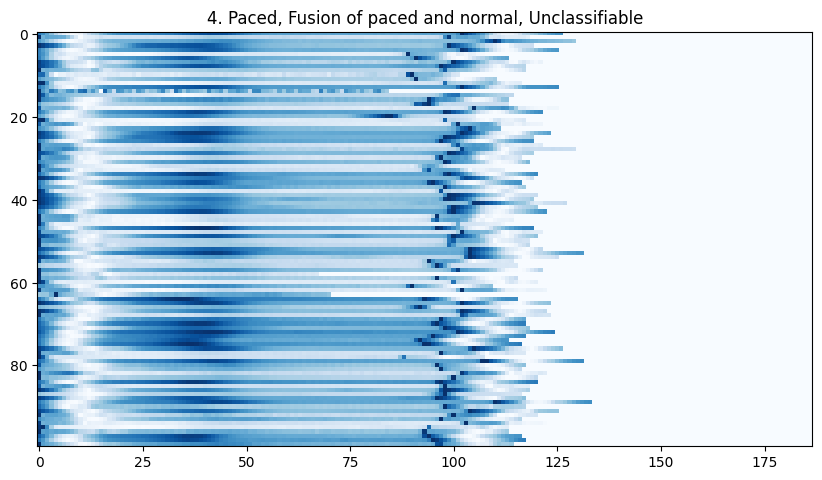

In [5]:
def class_spec(data, classnumber, n_samples):

    fig = plt.figure(figsize=(10,13))
    if type(data)==pd.DataFrame: 
        # wez wszystkie wiersze data gdzie jest szukany class number a nastepnie n_samples wierszy       
        plt.imshow(data[y_train==classnumber].iloc[:n_samples,:], 
               cmap="Blues", interpolation="nearest")
    else:
        plt.imshow(data[y_train==classnumber][:n_samples,:], 
               cmap="Blues", interpolation="nearest")
    plt.title(classes_description[i])
    plt.show()
    
for i in range(len(classes_description)):
    class_spec(X_train, i, 100)

preprocessing

In [6]:
from scipy.signal.windows import gaussian
from scipy.signal import decimate
from scipy.sparse import csr_matrix

w surowym sygnalu mamy duzo szumu
- male czestotliwosci to wlasciwa praca serca (P, QRS, T)
- duze czestotliuwosci to drzenie miesni, zaklocenia z sieci etc

Musimy usunac mozliwie ze najwieksze czestotliwosci zeby model nie uczyl sie na poszarpanych sygnalach.
jestes model stwierdzi ze szum koreluje sie z chorobą to jestesmy w dupie

dodatkowo, mozemy potem bezpiecznie zmniejszyc liczbe probek (zeby byl mniejszy input i szybsze uczenie) obnizajac przez filtr czestotliwosc (nyquist shannon)

uzywamy filtru gaussowskiego (wygladzanie low pass filter)
dziala to ze wartocs sygnalu w danym punkcie jest zastepowana srednia wazona jej sasiadow

w zwyczajnej sredniej traktujemy wszystko jako rowne przez co srednia moze wyjsc slabo
jesli robimy to przez krzywa gausa to daje nam inteligentne wagi np jak jestesmy w srodku to sasiad oddalony daleko bedzie bardzo slaby czyli nie rozwali nam sredniej


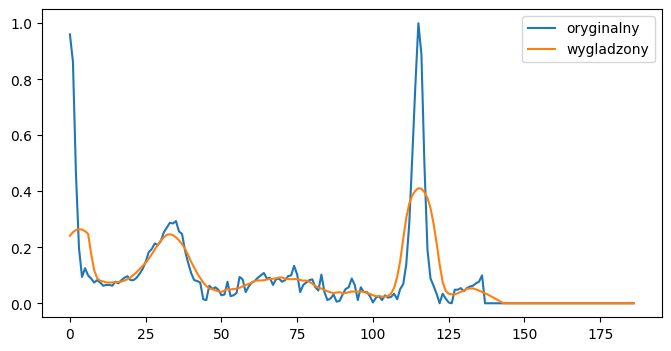

In [8]:
def gaussian_smoothing(data, window, std):
    gauss = gaussian(window, std, sym=True)
    data = np.convolve(gauss/gauss.sum(), data, mode='same')
    return data

def gauss_wrapper(data):
    return gaussian_smoothing(data, 12, 7)

fig = plt.figure(figsize=(8,4))
plt.plot(X_train.iloc[1,:], label="oryginalny")
plt.plot(gauss_wrapper(X_train.iloc[1,:]), label="wygladzony")
plt.legend()

tutaj dodajemy torcvhe sztucznych cech do danych ktore umozliwia modelowi lepsze wybory

laczymy 3 rzeczy w jeden zestaw:
- wartosc napiecia w danej cwhili
- jak szybko to napiecie rosnie lub spada
- jak szybko zmienia sie predkosc tych zmian

robimy to zeby model mogl roznic czy wartosc np 1mv powstala w wyniku syzbkiego piku czy jednak jest to taka dluzsza stala wartosc w sygnale



dodatkowo w funkcji preprocess usredniamy piki tzn. nie inetersuje nas czy szczyt wystapik w 100ms czy 102ms ale ze wystapil w oknie np 7ms
to rozmazuje sygnal zostawiajac tytlko najwazniejsze uderzenia

przez decimate() robimy downsampling i zatrzymuje co 5 probke zeby przyspieszyc uczenie. mozemy to zrobic bo wygladzilismy sygnal.

C:\Users\HARDPC\AppData\Local\Temp\ipykernel_1936\2133891248.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  data = data.abs().rolling(7, axis=1).max()
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_1936\2133891248.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill",axis=1)
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_1936\2133891248.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  data = data.abs().rolling(7, axis=1).max()
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_1936\2133891248.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill",axis=1)


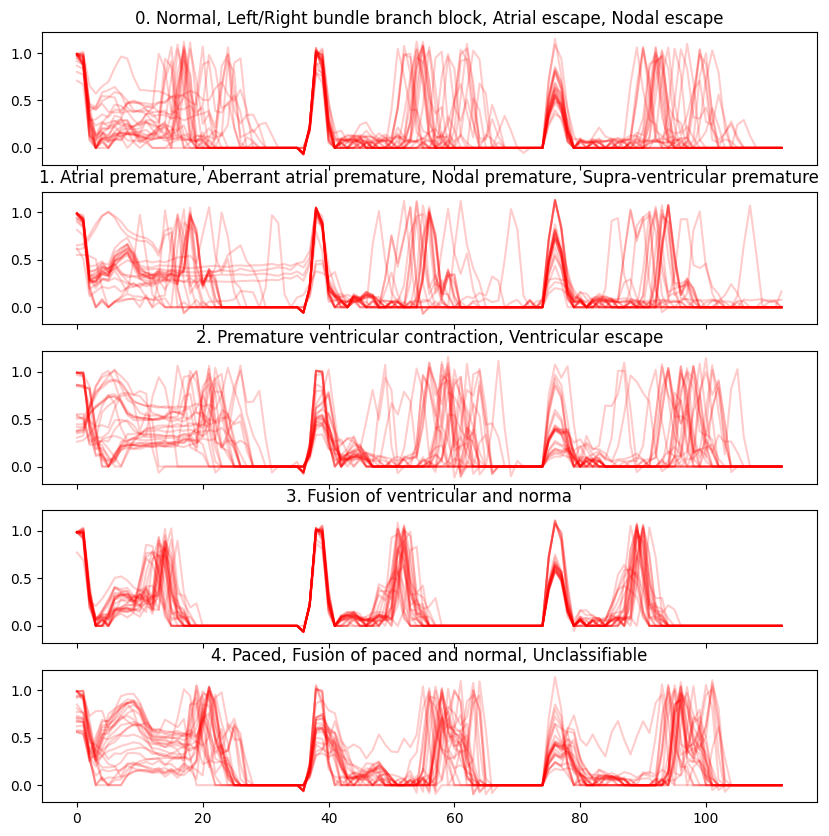

In [ ]:
def gradient(data, normalize=True):
    data = data.diff(axis=1, periods=3)
    if normalize:
        data = data.apply(lambda x: x/x.abs().max(), axis=1)
    return data

def preprocess(data): 
    data = data.abs().rolling(7, axis=1).max()
    data = data.fillna(method="bfill",axis=1)
    data = decimate(data, axis=1, q=5)
    data[np.abs(data) < .05] = 0
    return pd.DataFrame(data)

x_train_grad = gradient(X_train)
x_test_grad = gradient(X_test)

x_train_preprocessed = preprocess(pd.concat([X_train, x_train_grad, gradient(x_train_grad)], axis=1))
x_test_preprocessed = preprocess(pd.concat([X_test, x_test_grad, gradient(x_test_grad)], axis=1))

plot(x_train_preprocessed, y_train)

pokazanie tego na mapie ciepla

In [ ]:
for i in range(len(classes_description)):
    class_spec(x_train_preprocessed, i, 200)

In [15]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report

robimy po prostu regresje logityczna

robimy technika ovr (one versur rest) i tak naprawde tworzymy tyle modeli ile mamy klas i kazdy z nich bedzie sprawdzal czy dane sa akurat jego chorobą a wygrywa ten model ktory zwroci najwieksze prawdopodobniestwo

do roziwazywania korzystamy z metody newtona dzieki temu model wie jak szybko zmienia sie anchylenie i moze robic skoki w kierunku minimum

dlaczego akurat to? bo nie ma czasu na nic lepszego jak deep learning czy inne gowno, a regresja logistyczna w polaczeniu z metodą newtona bardzo dobrze dziala


In [ ]:
model = LogisticRegression(multi_class="ovr",solver="newton-cg", class_weight="balanced",
                          n_jobs=2, max_iter=150, C=.5)

x_train_sparse = csr_matrix(x_train_preprocessed)
start_time = time.time()
model.fit(x_train_sparse,y_train)
print("training time {}".format(time.time()-start_time))